In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import tracemalloc
import time
import warnings
from itertools import combinations
from collections import defaultdict, Counter
from typing import List, Dict, Set, Tuple, FrozenSet, Optional
%matplotlib inline

In [3]:
PALETTE   = ["#2E75B6", "#70AD47", "#ED7D31"]   # Blue=Apriori, Green=ECLAT, Orange=FP-Growth
ALG_NAMES = ["Apriori", "ECLAT", "FP-Growth"]

In [4]:
data1 = pd.read_csv("datasets/Groceries_dataset.csv")
data1['Date'] = pd.to_datetime(data1['Date'])
data1 = data1.sort_values(['Member_number', 'Date'])

# ── Apriori: Build Baskets (Member + Date) ────────
transactions_list = (
    data1.groupby(['Member_number', 'Date'])['itemDescription']
    .apply(list)
    .values.tolist()
)
print(f"Total baskets: {len(transactions_list)}")
print("First 3 basket examples:")
for basket in transactions_list[:3]:
    print(" ", basket)

/tmp/ipykernel_11209/4202137764.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data1['Date'] = pd.to_datetime(data1['Date'])


Total baskets: 14963
First 3 basket examples:
  ['whole milk', 'pastry', 'salty snack']
  ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
  ['soda', 'pickled vegetables']


In [5]:
max_len = 0
for i in transactions_list:
    length = len(i)
    max_len = max(length, max_len)
print(max_len)

11


In [6]:
df1 = pd.DataFrame(transactions_list)
df1

,0,1,2,3,4,5,6,7,8,9,10
0,whole milk,pastry,salty snack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sausage,whole milk,semi-finished bread,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,soda,pickled vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,canned beer,misc. beverages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sausage,hygiene articles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
14958,butter milk,whipped/sour cream,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14959,bottled water,herbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14960,fruit/vegetable juice,onions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14961,bottled beer,other vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df2 = pd.read_csv("datasets/Groceries_data1.csv")
df2.columns = range(len(df2.columns))
df2

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,whole milk,butter,yogurt,rice,abrasive cleaner,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,sausage,chicken,beef,hamburger meat,citrus fruit,grapes,root vegetables,whole milk,butter,whipped/sour cream,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9830,cooking chocolate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9831,chicken,citrus fruit,other vegetables,butter,yogurt,frozen dessert,domestic eggs,rolls/buns,rum,cling film/bags,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9832,semi-finished bread,bottled water,soda,bottled beer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = pd.concat([df1, df2], axis=0)
print(df.head())
print(df.shape)

            0                   1                    2       3    4    5   \
0   whole milk              pastry          salty snack     NaN  NaN  NaN   
1      sausage          whole milk  semi-finished bread  yogurt  NaN  NaN   
2         soda  pickled vegetables                  NaN     NaN  NaN  NaN   
3  canned beer     misc. beverages                  NaN     NaN  NaN  NaN   
4      sausage    hygiene articles                  NaN     NaN  NaN  NaN   

    6    7    8    9   ...   22   23   24   25   26   27   28   29   30   31  
0  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
3  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
4  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 32 columns]
(24797, 32)


## Exploring Dataset

In [9]:
print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


Summary statistics:
                0           1           2           3           4     5   \
count        24797       22638       10915        6918        4524  3325   
unique         166         165         162         159         157   139   
top     whole milk  whole milk  whole milk  whole milk  rolls/buns  soda   
freq          1800        1637         750         426         211   171   

          6              7     8              9   ...       22            23  \
count   2505           1880  1297            897  ...       14             8   
unique   140            143   131            120  ...       13             7   
top     soda  shopping bags  soda  shopping bags  ...  waffles  bottled beer   
freq     128             83    64             49  ...        2             2   

               24             25                26       27  \
count           7              7                 6        5   
unique          6              7                 5        4   
top     

In [10]:
transaction_lengths = df.notna().sum(axis=1)
print(transaction_lengths.describe())

count    24797.000000
mean         3.312014
std          2.579678
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         32.000000
dtype: float64


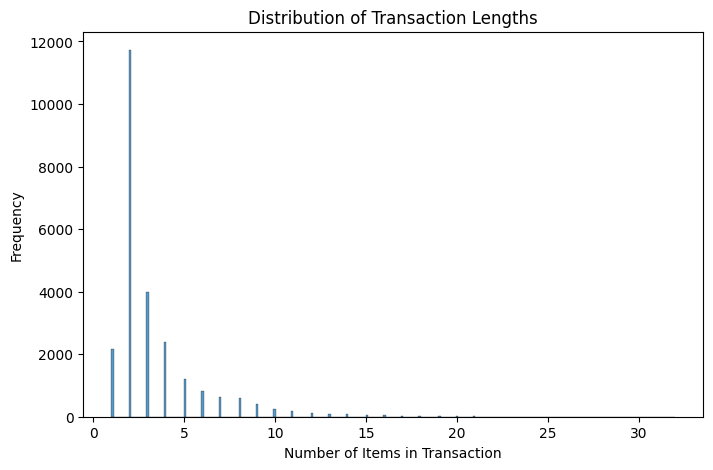

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(transaction_lengths)
plt.title("Distribution of Transaction Lengths")
plt.xlabel("Number of Items in Transaction")
plt.ylabel("Frequency")
plt.show()

In [12]:
#flatten dataset
items = pd.Series(df.values.ravel())
items = items.dropna()
print(items)

0               whole milk
1                   pastry
2              salty snack
32                 sausage
33              whole milk
                ...       
793472             chicken
793473      tropical fruit
793474    other vegetables
793475             vinegar
793476       shopping bags
Length: 82128, dtype: str


In [13]:
top_items = items.value_counts().head(40)
print(top_items)

whole milk                  5015
other vegetables            3801
rolls/buns                  3525
soda                        3229
yogurt                      2706
root vegetables             2143
tropical fruit              2064
bottled water               2020
sausage                     1848
shopping bags               1700
pastry                      1660
citrus fruit                1625
pip fruit                   1488
canned beer                 1481
bottled beer                1479
newspapers                  1381
whipped/sour cream          1367
fruit/vegetable juice       1229
brown bread                 1209
domestic eggs               1190
frankfurter                 1160
pork                        1133
butter                      1079
margarine                   1066
coffee                      1047
curd                        1038
beef                        1032
frozen vegetables            898
napkins                      850
chocolate                    845
chicken   

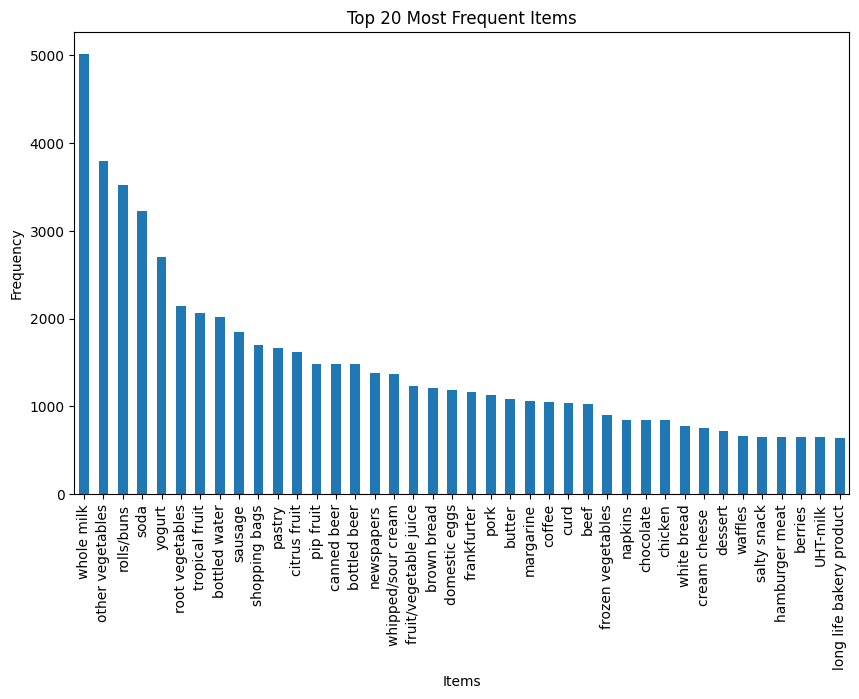

In [14]:
plt.figure(figsize=(10,6))
top_items.plot(kind="bar")
plt.title("Top 20 Most Frequent Items")
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.show()

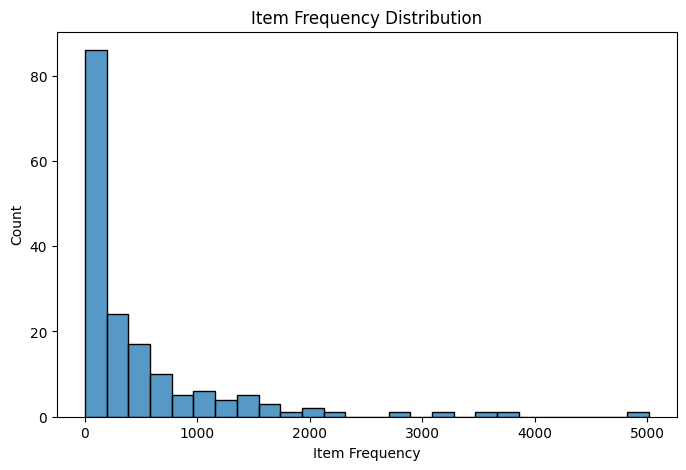

In [15]:
item_counts = items.value_counts()

plt.figure(figsize=(8,5))
sns.histplot(item_counts)
plt.title("Item Frequency Distribution")
plt.xlabel("Item Frequency")
plt.show()

In [16]:
unique_items = items.nunique()
print("Total unique items:", unique_items)

Total unique items: 169


In [17]:
total_cells = df.shape[0] * df.shape[1]
non_null = df.notnull().sum().sum()
sparsity = 1 - (non_null / total_cells)
print("Dataset sparsity:", sparsity)

Dataset sparsity: 0.8964995765616809


## Dataset is ready to use

### Apriori

In [18]:
def apriori_init_pass(transactions):
    counts = {}
    for t in transactions:
        for item in t:
            key = frozenset([item])
            counts[key] = counts.get(key, 0) + 1
    return counts


def apriori_candidate_gen(Fk_prev: Set[FrozenSet]) -> Set[FrozenSet]:
    Ck = set()
    lst = list(Fk_prev)
    for i in range(len(lst)):
        for j in range(i + 1, len(lst)):
            f1, f2 = sorted(lst[i]), sorted(lst[j])
            if f1[:-1] == f2[:-1] and f1[-1] < f2[-1]:
                c = frozenset(f1 + [f2[-1]])
                if all(c - {x} in Fk_prev for x in c):
                    Ck.add(c)
    return Ck


def apriori(transactions: List[List[str]], minsup: float):
    n   = len(transactions)
    thr = minsup * n
    F1  = {fs: cnt for fs, cnt in apriori_init_pass(transactions).items()
           if cnt >= thr}
    F_all, Fk_prev = dict(F1), set(F1.keys())
    k   = 2
    level_counts = {1: len(F1)}

    while Fk_prev:
        Ck = apriori_candidate_gen(Fk_prev)
        if not Ck:
            break
        Ck_cnt = {c: 0 for c in Ck}
        for t in transactions:
            ts = set(t)
            for c in Ck:
                if c.issubset(ts):
                    Ck_cnt[c] += 1
        Fk = {c: cnt for c, cnt in Ck_cnt.items() if cnt >= thr}
        F_all.update(Fk)
        Fk_prev = set(Fk.keys())
        level_counts[k] = len(Fk)
        k += 1

    return F_all, n, level_counts

### Eclat

In [19]:
def eclat(transactions: List[List[str]], minsup: float):
    n     = len(transactions)
    thr   = int(minsup * n)

    # Build TID-lists
    item_tid: Dict[str, Set[int]] = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in set(t):
            item_tid[item].add(tid)

    freq1 = {frozenset([item]): tids
             for item, tids in item_tid.items() if len(tids) >= thr}
    F_all = dict(freq1)

    def recurse(prefix: FrozenSet, items: List[Tuple[FrozenSet, Set[int]]]):
        for i in range(len(items)):
            fs_i, tids_i = items[i]
            new_fs = prefix | fs_i
            F_all[new_fs] = tids_i
            suffix = []
            for j in range(i + 1, len(items)):
                fs_j, tids_j = items[j]
                inter = tids_i & tids_j
                if len(inter) >= thr:
                    suffix.append((fs_j, inter))
            if suffix:
                recurse(new_fs, suffix)

    lst = list(freq1.items())
    for i in range(len(lst)):
        fs_i, tids_i = lst[i]
        suffix = []
        for j in range(i + 1, len(lst)):
            fs_j, tids_j = lst[j]
            inter = tids_i & tids_j
            if len(inter) >= thr:
                suffix.append((fs_j, inter))
        if suffix:
            recurse(fs_i, suffix)

    # Convert TID-sets → counts
    counts = {fs: len(tids) for fs, tids in F_all.items()}
    level_counts = {}
    for fs in counts:
        k = len(fs)
        level_counts[k] = level_counts.get(k, 0) + 1
    return counts, n, level_counts

### FP Growth

In [20]:
class FPNode:
    __slots__ = ("item", "count", "parent", "children", "link")
    def __init__(self, item, count, parent):
        self.item     = item
        self.count    = count
        self.parent   = parent
        self.children: Dict[str, "FPNode"] = {}
        self.link: Optional["FPNode"] = None

class FPTree:
    def __init__(self):
        self.root   = FPNode(None, 0, None)
        self.header: Dict[str, list] = {}   # item → [total_count, first_node]

    def insert(self, transaction: List[str], count: int = 1):
        cur = self.root
        for item in transaction:
            if item in cur.children:
                cur.children[item].count += count
            else:
                node = FPNode(item, count, cur)
                cur.children[item] = node
                if item not in self.header:
                    self.header[item] = [count, node]
                else:
                    self.header[item][0] += count
                    last = self.header[item][1]
                    while last.link:
                        last = last.link
                    last.link = node
            cur = cur.children[item]

    def is_single_path(self):
        node = self.root
        while node.children:
            if len(node.children) > 1:
                return False
            node = next(iter(node.children.values()))
        return True


def _build_tree(transactions, thr, freq_items=None):
    if freq_items is None:
        freq_items = Counter(item for t in transactions for item in t)
        freq_items = {i: c for i, c in freq_items.items() if c >= thr}
    tree = FPTree()
    for t in transactions:
        filtered = sorted([i for i in t if i in freq_items],
                          key=lambda x: (-freq_items[x], x))
        if filtered:
            tree.insert(filtered)
    return tree, freq_items


def _mine_tree(tree: FPTree, thr: int, prefix: FrozenSet, result: Dict):
    if tree.is_single_path():
        path = []
        node = tree.root
        while node.children:
            node = next(iter(node.children.values()))
            path.append(node)
        for r in range(1, len(path) + 1):
            for combo in combinations(path, r):
                fs  = prefix | frozenset(n.item for n in combo)
                cnt = min(n.count for n in combo)
                if cnt >= thr:
                    result[fs] = cnt
        return

    for item in sorted(tree.header, key=lambda x: tree.header[x][0]):
        new_fs  = prefix | frozenset([item])
        support = tree.header[item][0]
        if support >= thr:
            result[new_fs] = support

        # Build conditional pattern base
        cond = []
        node = tree.header[item][1]
        while node:
            path, par = [], node.parent
            while par.item is not None:
                path.append(par.item)
                par = par.parent
            cond.extend([path] * node.count)
            node = node.link

        if cond:
            cond_freq = Counter(i for p in cond for i in p)
            cond_freq = {i: c for i, c in cond_freq.items() if c >= thr}
            if cond_freq:
                cond_tree, _ = _build_tree(cond, thr, cond_freq)
                _mine_tree(cond_tree, thr, new_fs, result)


def fp_growth(transactions: List[List[str]], minsup: float):
    n   = len(transactions)
    thr = int(minsup * n)
    tree, _ = _build_tree(transactions, thr)
    result  = {}
    _mine_tree(tree, thr, frozenset(), result)
    level_counts = {}
    for fs in result:
        k = len(fs)
        level_counts[k] = level_counts.get(k, 0) + 1
    return result, n, level_counts

### Rule Generation

In [21]:
def generate_rules(F_all: Dict[FrozenSet, int], n: int,
                   min_conf: float = 0.10) -> List[Dict]:
    rules = []
    for itemset in F_all:
        if len(itemset) < 2:
            continue
        for r in range(1, len(itemset)):
            for ant in map(frozenset, combinations(itemset, r)):
                if ant not in F_all:
                    continue
                con        = itemset - ant
                support    = F_all[itemset] / n
                confidence = F_all[itemset] / F_all[ant]
                lift       = confidence / (F_all[con] / n) if con in F_all else 0
                if confidence >= min_conf:
                    rules.append({
                        "antecedent": ant,
                        "consequent": con,
                        "support"   : support,
                        "confidence": confidence,
                        "lift"      : lift,
                    })
    return sorted(rules, key=lambda x: -x["confidence"])

### Recommendation engine

In [22]:
def recommend(basket: List[str], rules: List[Dict], top_n: int = 5):
    basket_set = frozenset(basket)
    scores: Dict[str, float] = {}
    for rule in rules:
        if rule["antecedent"].issubset(basket_set):
            for item in rule["consequent"]:
                if item not in basket_set:
                    if item not in scores or rule["confidence"] > scores[item]:
                        scores[item] = rule["confidence"]
    return sorted(scores.items(), key=lambda x: -x[1])[:top_n]

### Benchmark

In [23]:
def benchmark(transactions, minsup):
    algos = {
        "Apriori"  : lambda: apriori(transactions, minsup),
        "ECLAT"    : lambda: eclat(transactions, minsup),
        "FP-Growth": lambda: fp_growth(transactions, minsup),
    }
    results = {}
    for name, fn in algos.items():
        tracemalloc.start()
        t0      = time.perf_counter()
        out     = fn()
        elapsed = time.perf_counter() - t0
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        F_all   = out[0]
        results[name] = {
            "time"    : elapsed,
            "memory"  : peak / 1024 / 1024,
            "itemsets": len(F_all),
            "F_all"   : F_all,
            "n"       : out[1],
            "levels"  : out[2],
        }
        print(f"  {name:<12}  time={elapsed:.3f}s  "
              f"mem={peak/1024/1024:.2f} MB  itemsets={len(F_all)}")
    return results

In [24]:
def save(fig, fname):
    fig.savefig(fname, dpi=150, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    print(f"  saved → {fname}")

### EDA Dashboard

In [25]:
def plot_eda(df, transactions):
    fig = plt.figure(figsize=(18, 5))
    fig.suptitle("Exploratory Data Analysis — Groceries Dataset",
                 fontsize=16, fontweight="bold", y=1.02)

    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    # Top-20 items
    ax1 = fig.add_subplot(gs[0, 0])
    top20 = items.value_counts().head(20)
    bars  = ax1.barh(top20.index[::-1], top20.values[::-1],
                     color="#2E75B6", edgecolor="white", height=0.7)
    ax1.bar_label(bars, padding=3, fontsize=8)
    ax1.set_xlabel("Transaction Count")
    ax1.set_title("Top 20 Most Purchased Items", fontweight="bold")
    ax1.set_xlim(0, top20.max() * 1.15)


    # Item support
    ax3 = fig.add_subplot(gs[0, 1])
    n = len(transactions)
    top10 = items.value_counts().head(10)

    ax3.barh(top10.index[::-1], (top10.values[::-1] / n) * 100,
             color="#70AD47", edgecolor="white", height=0.7)
    ax3.set_xlabel("Support (%)")
    ax3.set_title("Top-10 Item Support %", fontweight="bold")
    plt.show()
    save(fig, "plot_01_eda.png")

###  Multi-threshold sensitivity

In [26]:

def plot_threshold_sensitivity(transactions):
    thresholds = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03]
    results    = {n: {"time": [], "itemsets": []} for n in ALG_NAMES}

    for thr in thresholds:
        for name, fn in zip(ALG_NAMES, [apriori, eclat, fp_growth]):
            t0  = time.perf_counter()
            out = fn(transactions, thr)
            results[name]["time"].append(time.perf_counter() - t0)
            results[name]["itemsets"].append(len(out[0]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Threshold Sensitivity Analysis",
                 fontsize=13, fontweight="bold")

    thr_pct = [t * 100 for t in thresholds]
    for i, name in enumerate(ALG_NAMES):
        axes[0].plot(thr_pct, results[name]["time"], marker="o",
                     color=PALETTE[i], linewidth=2, label=name)
        axes[1].plot(thr_pct, results[name]["itemsets"], marker="s",
                     color=PALETTE[i], linewidth=2, label=name)

    axes[0].set_xlabel("Minimum Support (%)")
    axes[0].set_ylabel("Execution Time (s)")
    axes[0].set_title("Execution Time vs. Min Support")
    axes[0].legend()

    axes[1].set_xlabel("Minimum Support (%)")
    axes[1].set_ylabel("Frequent Itemsets Found")
    axes[1].set_title("Itemsets Found vs. Min Support")
    axes[1].legend()

    for ax in axes:
        ax.set_xticks(thr_pct)
        ax.set_xticklabels([f"{t:.1f}%" for t in thr_pct], rotation=30)

    plt.tight_layout()
    plt.show()
    save(fig, "plot_06_sensitivity.png")


### Benchmark Time and memory

In [27]:
def plot_benchmark(bench):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Algorithm Benchmark Comparison",
                 fontsize=14, fontweight="bold")

    names  = ALG_NAMES
    times  = [bench[n]["time"]     for n in names]
    mems   = [bench[n]["memory"]   for n in names]
    items  = [bench[n]["itemsets"] for n in names]

    # Time
    bars = axes[0].bar(names, times, color=PALETTE, edgecolor="white", width=0.5)
    axes[0].bar_label(bars, fmt="%.3f s", padding=4, fontsize=10, fontweight="bold")
    axes[0].set_ylabel("Execution Time (seconds)")
    axes[0].set_title("Execution Time", fontweight="bold")
    axes[0].set_ylim(0, max(times) * 1.3)

    # Memory
    bars2 = axes[1].bar(names, mems, color=PALETTE, edgecolor="white", width=0.5)
    axes[1].bar_label(bars2, fmt="%.2f MB", padding=4, fontsize=10, fontweight="bold")
    axes[1].set_ylabel("Peak Memory (MB)")
    axes[1].set_title("Peak Memory Usage", fontweight="bold")
    axes[1].set_ylim(0, max(mems) * 1.3)

    # Itemsets
    bars3 = axes[2].bar(names, items, color=PALETTE, edgecolor="white", width=0.5)
    axes[2].bar_label(bars3, padding=4, fontsize=10, fontweight="bold")
    axes[2].set_ylabel("Frequent Itemsets Found")
    axes[2].set_title("Frequent Itemsets Found", fontweight="bold")
    axes[2].set_ylim(0, max(items) * 1.2)

    for ax in axes:
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, fontsize=11)

    patches = [mpatches.Patch(color=PALETTE[i], label=names[i])
               for i in range(3)]
    fig.legend(handles=patches, loc="lower center", ncol=3,
               frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()
    save(fig, "plot_02_benchmark.png")


### Itemsets per Level per Algorithm

In [28]:
def plot_levels(bench):
    fig, ax = plt.subplots(figsize=(10, 6))
    max_k   = max(max(v["levels"].keys()) for v in bench.values())
    x       = np.arange(1, max_k + 1)
    width   = 0.25

    for i, name in enumerate(ALG_NAMES):
        lvl    = bench[name]["levels"]
        counts = [lvl.get(k, 0) for k in x]
        offset = (i - 1) * width
        bars   = ax.bar(x + offset, counts, width, label=name,
                        color=PALETTE[i], edgecolor="white")
        ax.bar_label(bars, padding=2, fontsize=9, fontweight="bold")

    ax.set_xlabel("Itemset Size (k)", fontsize=12)
    ax.set_ylabel("Number of Frequent Itemsets", fontsize=12)
    ax.set_title("Frequent Itemsets per Level — All Algorithms",
                 fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"k = {k}" for k in x], fontsize=11)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    save(fig, "plot_03_levels.png")

### top frequent itemset

In [29]:
def plot_top_pairs(F_all, n, title, color, fname):
    pairs = [(", ".join(sorted(fs)), cnt / n)
             for fs, cnt in F_all.items() if len(fs) == 2]
    if not pairs:
        return
    pairs = sorted(pairs, key=lambda x: -x[1])[:15]
    labels, sups = zip(*pairs)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], sups[::-1], color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xlabel("Support", fontsize=11)
    ax.set_title(f"Top 15 Frequent Item Pairs — {title}",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, max(sups) * 1.18)
    plt.tight_layout()
    plt.show()
    save(fig, fname)

### Support vs Confidence scatter (rules)

In [30]:
def plot_scatter(rules, title, color, fname):
    if not rules:
        return
    sups  = [r["support"]    for r in rules]
    confs = [r["confidence"] for r in rules]
    lifts = [r["lift"]       for r in rules]

    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sups, confs, c=lifts, cmap="YlOrRd",
                    s=60, alpha=0.75, edgecolors="white", linewidths=0.4)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Lift", fontsize=11)
    ax.set_xlabel("Support", fontsize=11)
    ax.set_ylabel("Confidence", fontsize=11)
    ax.set_title(f"Support vs. Confidence (colour = Lift)\n{title}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    save(fig, fname)

## Recommendation demo chart

In [31]:
def plot_recommendations(rules):
    test_baskets = [
        ["whole milk", "yogurt"],
        ["rolls/buns", "soda"],
        ["other vegetables", "root vegetables"],
        ["butter", "curd"],
        ["tropical fruit", "citrus fruit"],
    ]

    fig, axes = plt.subplots(1, len(test_baskets),
                              figsize=(20, 5), sharey=False)
    fig.suptitle("Recommendation Engine — Top-5 Suggestions per Basket",
                 fontsize=13, fontweight="bold")

    for ax, basket in zip(axes, test_baskets):
        recs = recommend(basket, rules, top_n=5)
        if not recs:
            ax.text(0.5, 0.5, "No rules\nfound",
                    ha="center", va="center", transform=ax.transAxes)
        else:
            items, confs = zip(*recs)
            colors_bar = plt.cm.Blues(np.linspace(0.4, 0.85, len(items)))
            ax.barh(range(len(items)), confs, color=colors_bar,
                    edgecolor="white")
            ax.set_yticks(range(len(items)))
            ax.set_yticklabels([f"{it[:20]}" for it in items], fontsize=9)
            ax.set_xlabel("Confidence")
            ax.set_xlim(0, 1.05)
            ax.axvline(0.5, color="red", linestyle="--",
                       alpha=0.4, linewidth=1)
        title = "\n+\n".join(basket)
        ax.set_title(f"Basket:\n{title}", fontsize=8, fontweight="bold")
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()
    save(fig, "plot_07_recommendations.png")

In [32]:
MINSUP = 0.003
MINCONF = 0.08
transactions = df.values.tolist()
transactions = [
    [str(item) for item in t if pd.notna(item)]
    for t in transactions
]
print(f"  Records: {len(df):,}  |  Transactions: {len(transactions):,}"
          f"  |  Unique items: {items.nunique()}")

  Records: 24,797  |  Transactions: 24,797  |  Unique items: 169


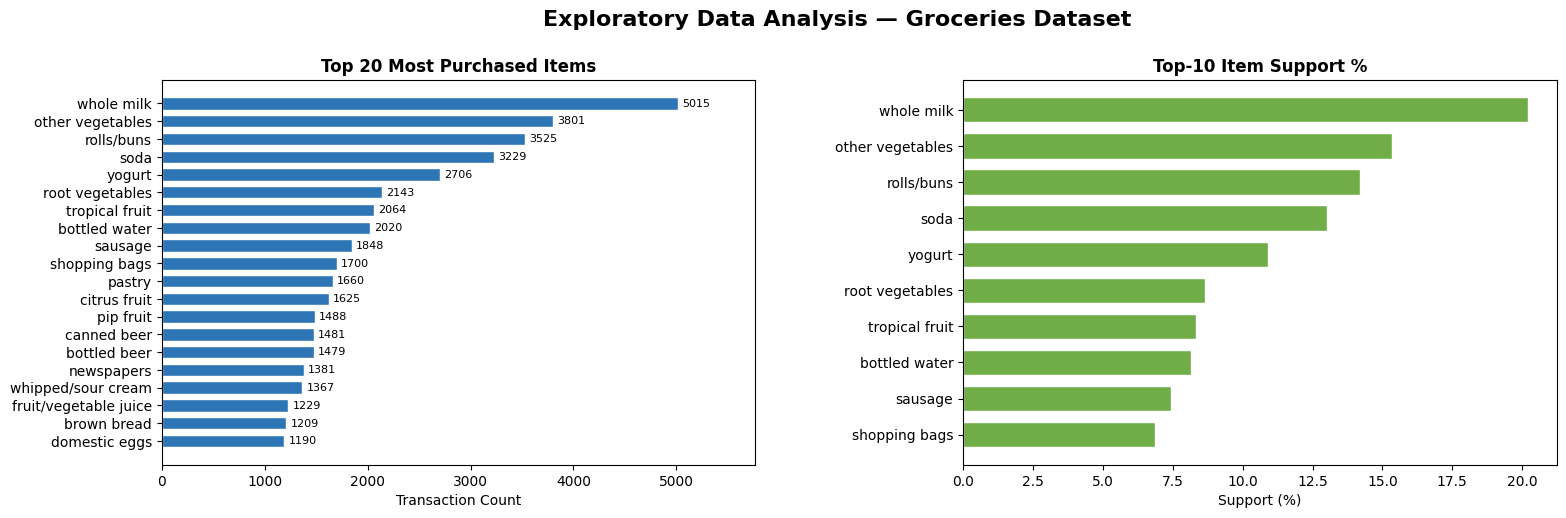

  saved → plot_01_eda.png


In [33]:
plot_eda(df, transactions)

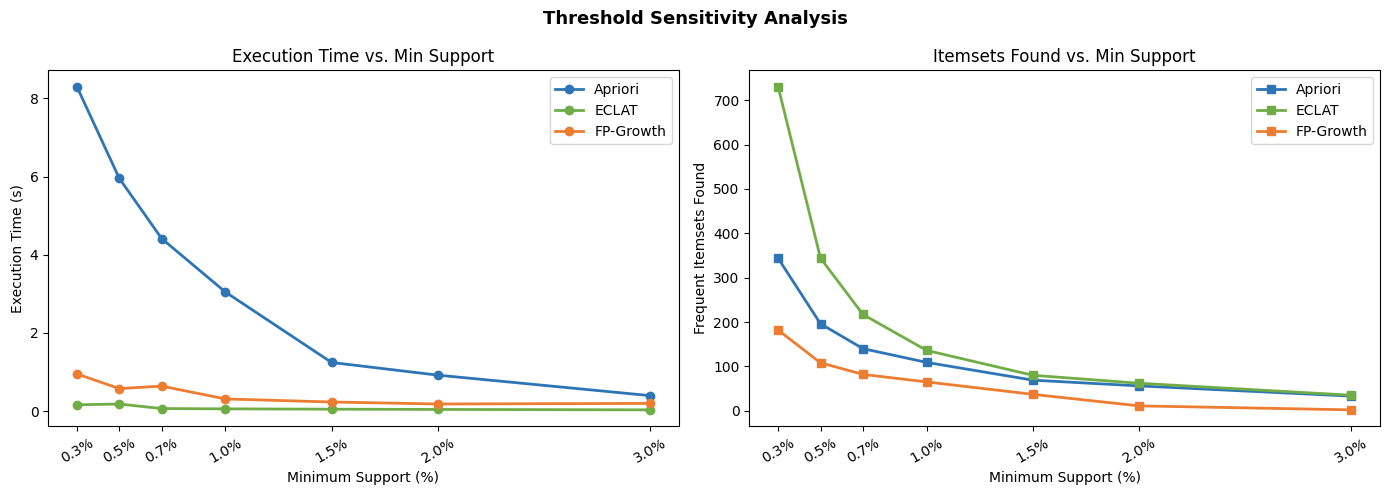

  saved → plot_06_sensitivity.png


In [34]:
plot_threshold_sensitivity(transactions)

In [35]:
bench = benchmark(transactions, MINSUP)

  Apriori       time=8.492s  mem=1.18 MB  itemsets=344
  ECLAT         time=0.187s  mem=10.86 MB  itemsets=731
  FP-Growth     time=1.540s  mem=7.54 MB  itemsets=182


In [36]:
F_apriori = bench["Apriori"]["F_all"]
n         = bench["Apriori"]["n"]
rules     = generate_rules(F_apriori, n, MINCONF)
# Sort by lift first (most interesting), then by confidence
rules_by_lift = sorted(rules, key=lambda x: -x["lift"])
print(f"  Association rules generated: {len(rules)}")

  Association rules generated: 259


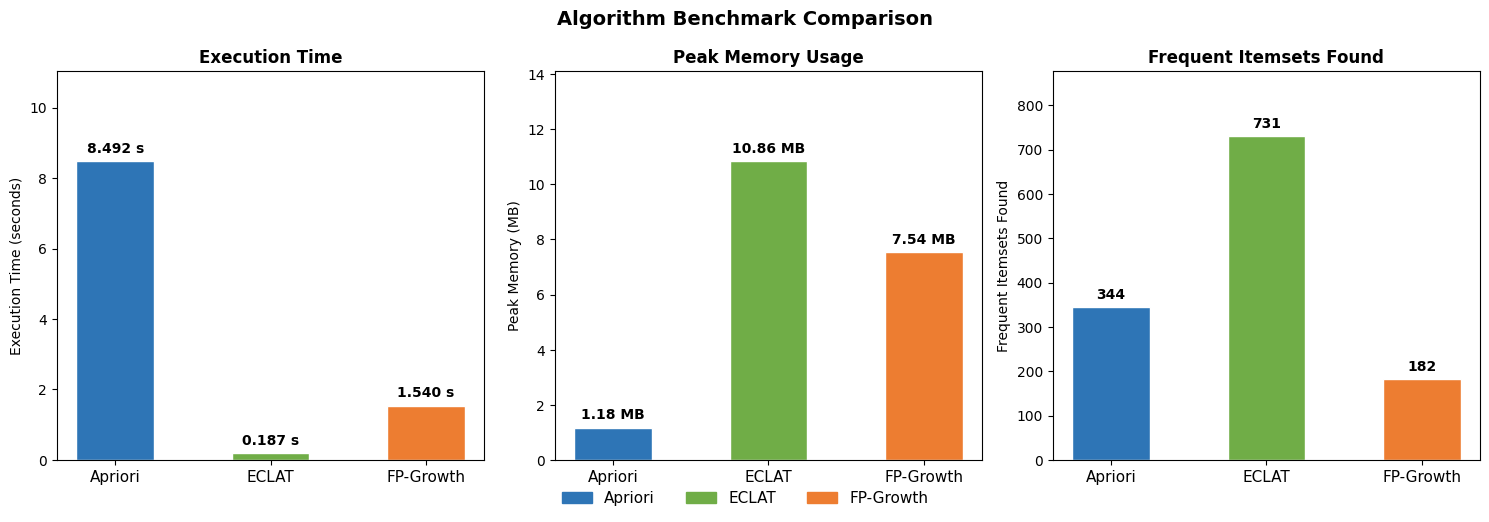

  saved → plot_02_benchmark.png


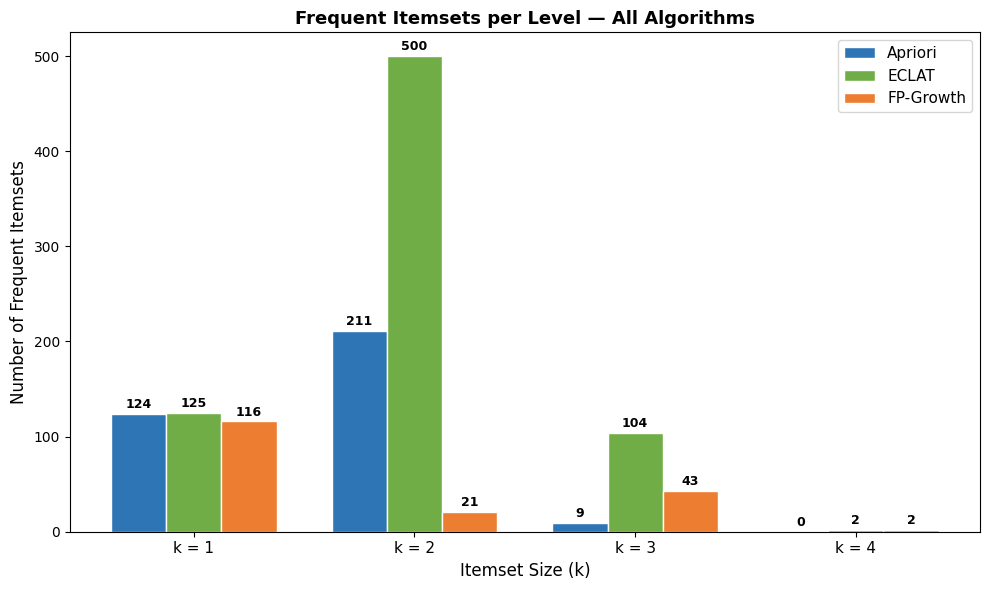

  saved → plot_03_levels.png


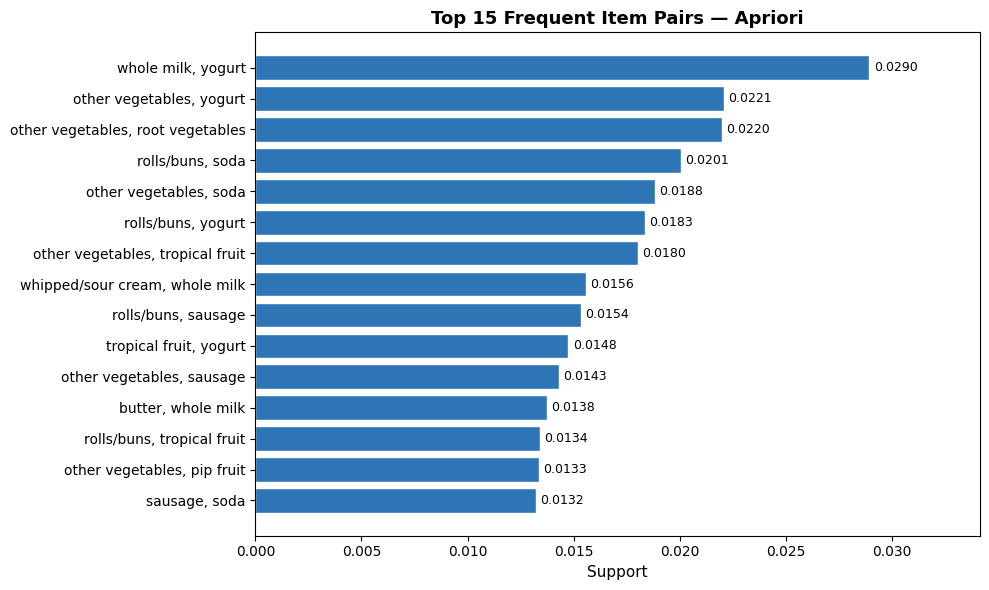

  saved → plot_04_pairs_apriori.png


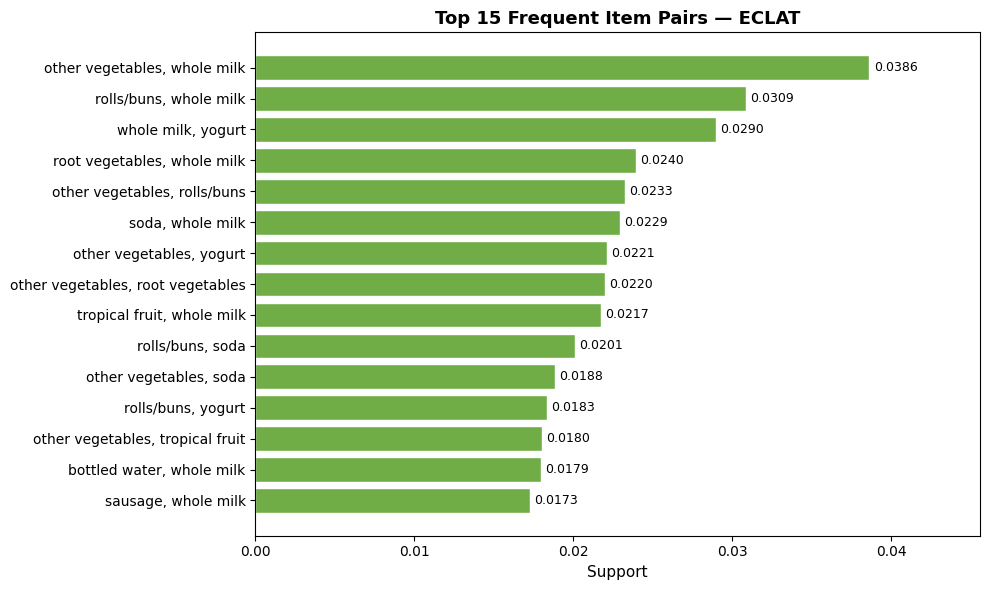

  saved → plot_04_pairs_eclat.png


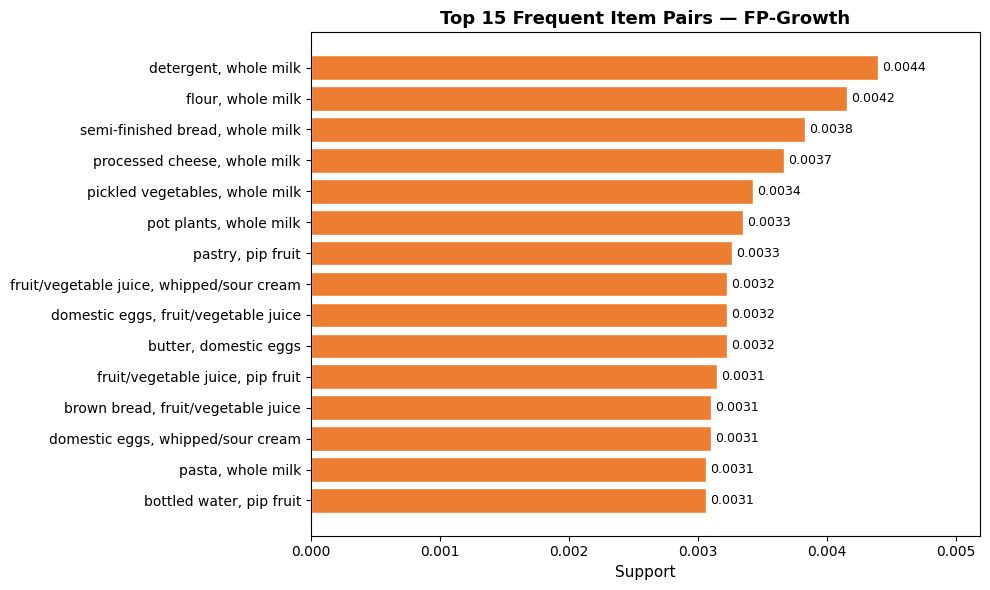

  saved → plot_04_pairs_fpg.png


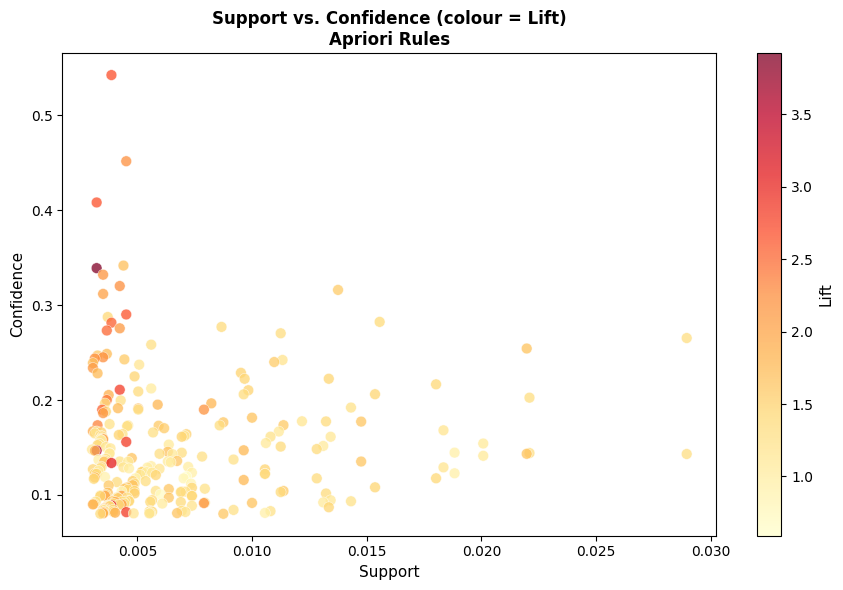

  saved → plot_05_scatter.png


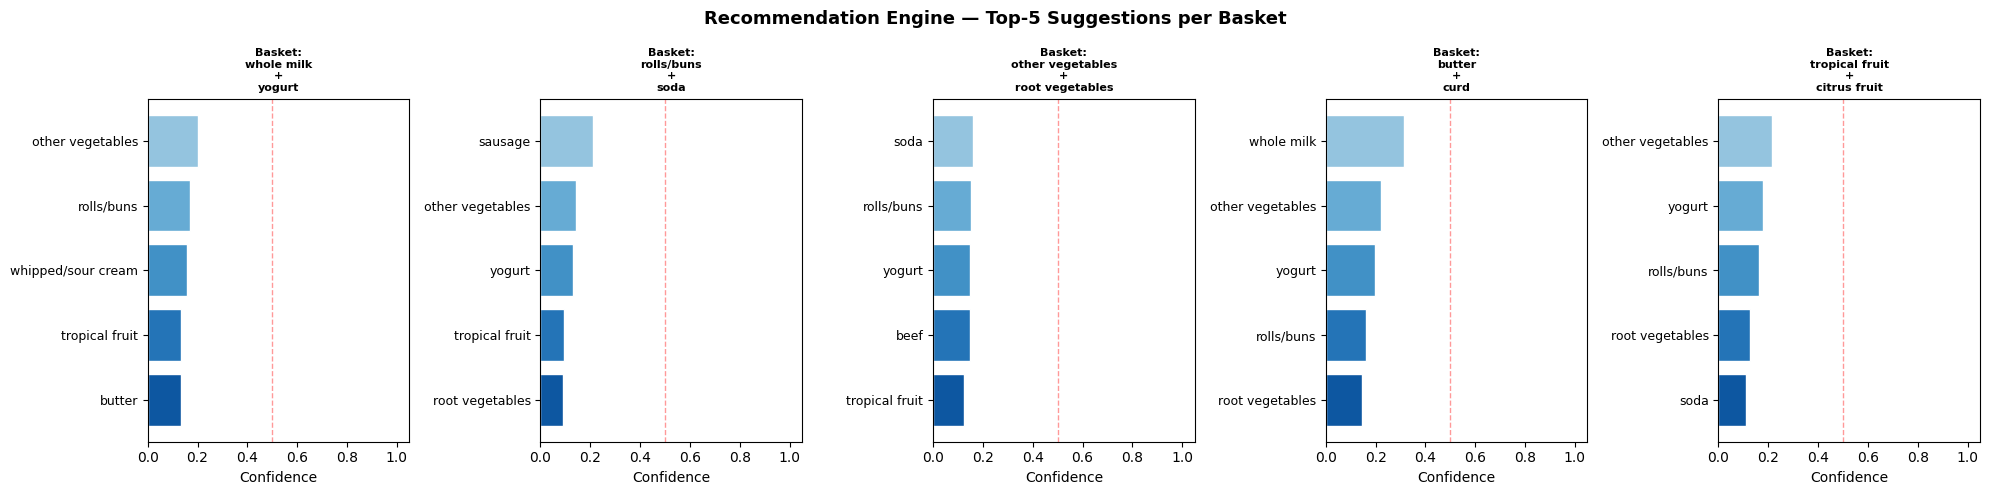

  saved → plot_07_recommendations.png


In [37]:
plot_benchmark(bench)
plot_levels(bench)
plot_top_pairs(F_apriori, n, "Apriori",   PALETTE[0], "plot_04_pairs_apriori.png")
plot_top_pairs(bench["ECLAT"]["F_all"],   bench["ECLAT"]["n"],     "ECLAT",     PALETTE[1], "plot_04_pairs_eclat.png")
plot_top_pairs(bench["FP-Growth"]["F_all"], bench["FP-Growth"]["n"], "FP-Growth", PALETTE[2], "plot_04_pairs_fpg.png")
plot_scatter(rules,       "Apriori Rules",  PALETTE[0], "plot_05_scatter.png")
plot_recommendations(rules)

In [38]:
print("  RECOMMENDATION DEMO")
print(f"{'═'*60}")
demos = [
    ["whole milk", "yogurt"],
    ["rolls/buns", "soda"],
    ["butter", "curd"],
    ["other vegetables", "root vegetables"],
]
for basket in demos:
    recs = recommend(basket, rules_by_lift, top_n=5)
    print(f"\n  Basket : {basket}")
    print(f"  Recommendations:")
    for item, conf in recs:
        print(f"    ➤  {item:<35} confidence = {conf:.4f}")

  RECOMMENDATION DEMO
════════════════════════════════════════════════════════════

  Basket : ['whole milk', 'yogurt']
  Recommendations:
    ➤  other vegetables                    confidence = 0.2025
    ➤  rolls/buns                          confidence = 0.1681
    ➤  whipped/sour cream                  confidence = 0.1560
    ➤  tropical fruit                      confidence = 0.1353
    ➤  butter                              confidence = 0.1337

  Basket : ['rolls/buns', 'soda']
  Recommendations:
    ➤  sausage                             confidence = 0.2108
    ➤  other vegetables                    confidence = 0.1446
    ➤  yogurt                              confidence = 0.1291
    ➤  tropical fruit                      confidence = 0.0945
    ➤  root vegetables                     confidence = 0.0922

  Basket : ['butter', 'curd']
  Recommendations:
    ➤  whole milk                          confidence = 0.3160
    ➤  other vegetables                    confidence = 0.2224
 